<a href="https://colab.research.google.com/github/BJut7021/TH_DeepLearning/blob/main/Lap_AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.1. Nạp thư viện

In [24]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

2.2. Nạp dataset

In [25]:
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


2.3. Xây dựng mô hình Autoencoder

In [26]:

encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(encoding_dim, activation='relu')(input_img)

decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoder_input = keras.Input(shape=(encoding_dim,))

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(encoder_input, decoder_layer(encoder_input))



2.4. Huấn luyện mô hình

In [27]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.0136 - loss: 0.2771 - val_accuracy: 0.0146 - val_loss: 0.1881
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0104 - loss: 0.1692 - val_accuracy: 0.0087 - val_loss: 0.1519
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0098 - loss: 0.1434 - val_accuracy: 0.0079 - val_loss: 0.1338
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0095 - loss: 0.1283 - val_accuracy: 0.0093 - val_loss: 0.1211
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0101 - loss: 0.1177 - val_accuracy: 0.0110 - val_loss: 0.1124
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0110 - loss: 0.1106 - val_accuracy: 0.0125 - val_loss: 0.1066
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0114 - loss: 0.1058 - val_accuracy: 0.0119 - val_loss: 0.1025
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.0119 - loss: 0.1023 - val_accu

2.5. Dự báo loại ảnh sử dụng Autoencoder

In [28]:
encoding_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoding_imgs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


2.6. Hiển thị ảnh từ mô hình Autoencoder

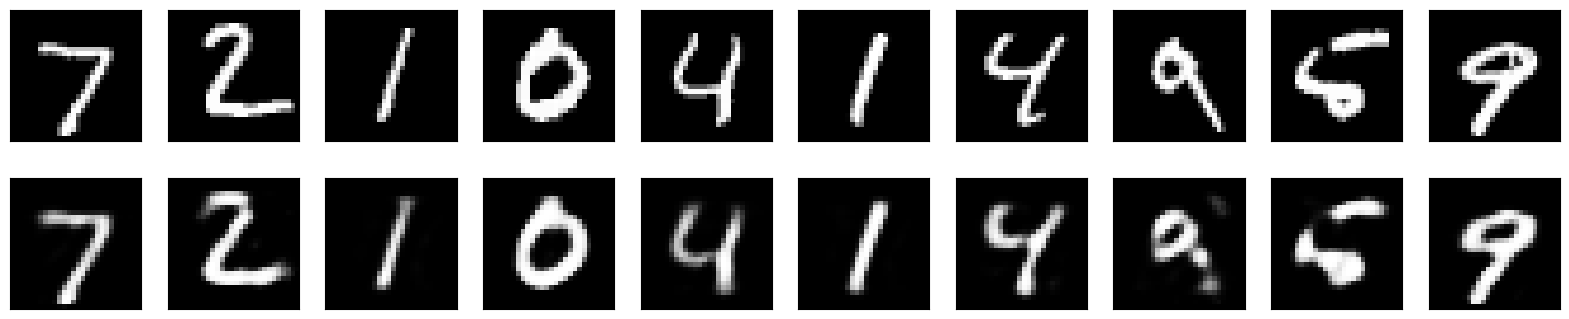

In [29]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i +1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

3. CẢI TIẾN AUTOENCODER


3.1. Thêm L1

In [30]:
from keras import regularizers

encoding = 32
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encoding_dim, activity_regularizer=regularizers.l1(10e-5), activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)
autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)
encoder_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoder_input, decoder_layer(encoder_input))

autoencoder.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

autoencoder.fit(x_train, x_train, epochs=100, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0146 - loss: 0.6549 - val_accuracy: 0.0161 - val_loss: 0.6155
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.0150 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.5275 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0149 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.3739 - 

3.2. Thêm layers

In [31]:
encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)
encoder_input = keras.Input(shape=(32,))

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(encoder_input, decoder_layer(encoder_input))

Bài tập

bài 1

Kích thước tập train câu 1: (50000, 32, 32, 3)
Kích thước tập test câu 1: (10000, 32, 32, 3)


Model: "functional_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_42 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 149s 188ms/step - loss: 0.0109 - val_loss: 0.0067
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 198s 183ms/step - loss: 0.0060 - val_loss: 0.0058
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 205s 188ms/step - loss: 0.0052 - val_loss: 0.0049
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 186ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 202s 186ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 205s 189ms/step - loss: 0.0044 - val_loss: 0.0044
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 185ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 146s 187ms/step - loss: 0.0041 - val_loss: 0.0041
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 185ms/step - loss: 0.0040 - val_loss: 0.0041
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 183ms/step - loss: 0.0039 - val_loss: 0.0039
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step


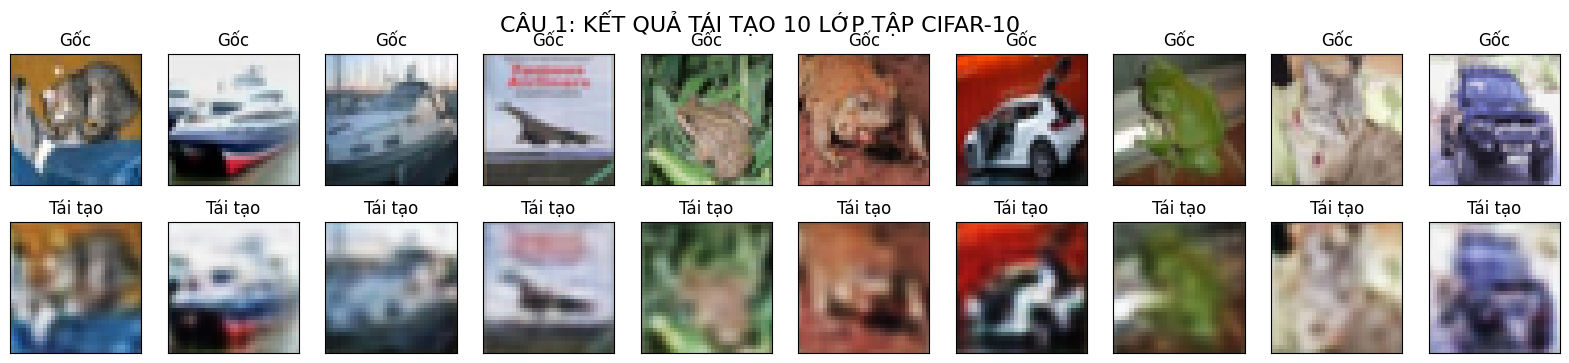

In [36]:


import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10


(x_train, y_train), (x_test, y_test) = cifar10.load_data()


x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Kích thước tập train câu 1: {x_train.shape}")
print(f"Kích thước tập test câu 1: {x_test.shape}")


input_img = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)  # Giảm xuống 16x16
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)  # Không gian nén không gian (Bottleneck): 8x8x16


x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)  # Tăng lên 16x16
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)  # Tăng lên 32x32
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)  # Đầu ra khôi phục 32x32x3


autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')
autoencoder.summary()


history = autoencoder.fit(x_train, x_train,
                          epochs=10,
                          batch_size=64,
                          shuffle=True,
                          validation_data=(x_test, x_test))


decoded_imgs = autoencoder.predict(x_test)

n = 10  # Số lượng ảnh hiển thị
plt.figure(figsize=(20, 4))
for i in range(n):
    # Hiển thị ảnh gốc
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Gốc")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)


    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Tái tạo")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("CÂU 1: KẾT QUẢ TÁI TẠO 10 LỚP TẬP CIFAR-10", fontsize=16)
plt.show()

bài 2


Kích thước tập train chỉ có Chó/Mèo: (10000, 32, 32, 3)
Kích thước tập test chỉ có Chó/Mèo: (2000, 32, 32, 3)
Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 375ms/step - loss: 0.0181 - val_loss: 0.0082
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 371ms/step - loss: 0.0070 - val_loss: 0.0059
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 382ms/step - loss: 0.0056 - val_loss: 0.0051
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 364ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 363ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 402ms/step - loss: 0.0042 - val_loss: 0.0040
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - loss: 0.0040 - val_loss: 0.0038
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 380ms/step - loss: 0.0039 - val_loss: 0.0037
Epoch 9/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 380ms/step - loss: 0.0037 - val_loss: 0.0036
Epoch 10/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 373ms/step - loss: 0.0036 - val_loss: 0.0035

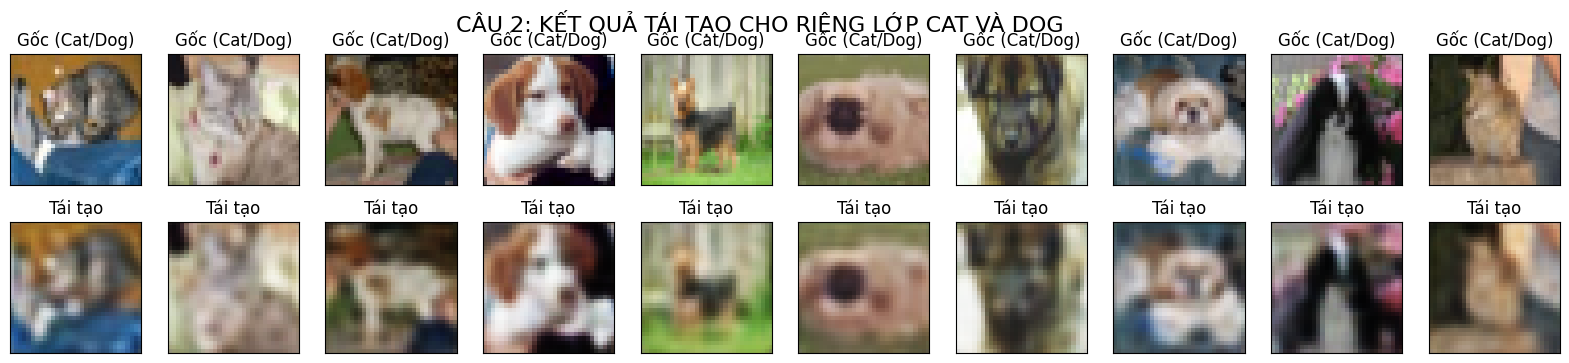

In [37]:

# Phẳng hóa y để dễ so sánh
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

# Tạo bộ lọc (mask) cho nhãn 3 và 5
train_mask = (y_train_flat == 3) | (y_train_flat == 5)
test_mask = (y_test_flat == 3) | (y_test_flat == 5)

x_train_cat_dog = x_train[train_mask]
x_test_cat_dog = x_test[test_mask]

print(f"Kích thước tập train chỉ có Chó/Mèo: {x_train_cat_dog.shape}")
print(f"Kích thước tập test chỉ có Chó/Mèo: {x_test_cat_dog.shape}")

# 2. Xây dựng mô hình Autoencoder riêng cho Chó & Mèo
input_img_cd = layers.Input(shape=(32, 32, 3))
# Encoder
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(input_img_cd)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded_cd = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded_cd)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded_cd = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_cd = models.Model(input_img_cd, decoded_cd)
autoencoder_cd.compile(optimizer='adam', loss='mean_squared_error')

# 3. Huấn luyện mô hình với dữ liệu Chó Mèo
history_cd = autoencoder_cd.fit(x_train_cat_dog, x_train_cat_dog,
                                 epochs=15,
                                 batch_size=64,
                                 shuffle=True,
                                 validation_data=(x_test_cat_dog, x_test_cat_dog))

# 4. Trực quan hóa kết quả tái tạo ảnh Chó/Mèo
decoded_imgs_cd = autoencoder_cd.predict(x_test_cat_dog)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Hiển thị ảnh gốc Chó/Mèo
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cat_dog[i])
    plt.title("Gốc (Cat/Dog)")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Hiển thị ảnh tái tạo tương ứng
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_cd[i])
    plt.title("Tái tạo")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("CÂU 2: KẾT QUẢ TÁI TẠO CHO RIÊNG LỚP CAT VÀ DOG", fontsize=16)
plt.show()